In [14]:
import pandas as pd
import numpy as np
import os
import shutil
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional
import sys
from lifelines import WeibullAFTFitter
import os 

sys.path.append('../../utilities')

from preprocess import preprocess

In [15]:
df_train = pd.read_csv('/home/dgxuser40/manjil/finsurv/participant_data/Repay/Liquidated/train.csv')
df_test = pd.read_csv('/home/dgxuser40/manjil/finsurv/participant_data/Repay/Liquidated/test_features.csv')

In [7]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# plt.figure(figsize=(50,50))
# co_mtx = df_train.corr(numeric_only=True)
# sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
# plt.savefig('corr.png', dpi=300)
# plt.show()

In [10]:
index_event = 'Repay'
outcome_event = 'Liquidated'

# Define path to the single participant data folder.
PARTICIPANT_DATA_PATH = '/home/dgxuser40/manjil/finsurv/participant_data'

In [11]:
dataset_path = os.path.join(index_event, outcome_event)
train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))
test_features_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'test_features.csv'))

In [13]:
X_train, y_train, X_test_processed = preprocess(train_df, test_features_df)

In [18]:
y_train_xgb = np.where(
            y_train['status'] == 1,
            y_train['timeDiff'],  # positive for events
            -y_train['timeDiff']  # negative for censored
        )
        
# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train_xgb)
dtest = xgb.DMatrix(X_test_processed)
        
# XGBoost parameters for survival analysis
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'max_depth': 5,
    'eta': 0.05,  # learning rate
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'lambda': 2.0,  # L2 regularization
    'alpha': 0.5,   # L1 regularization
    'seed': 42
}
        
print(f"Training XGBoost survival:cox model for {dataset_path}...")
model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    verbose_eval=False
)
print("  - Model trained successfully.")

# --- Generate and Save Predictions ---
print(f"Generating predictions for {dataset_path}...")
# Predict risk scores (higher score = higher risk)
predictions = -model.predict(dtest)

Training XGBoost survival:cox model for Repay/Liquidated...
  - Model trained successfully.
Generating predictions for Repay/Liquidated...


In [19]:
# get feature importance scores (by weight, gain, or cover)
importance = model.get_score(importance_type='gain')  # 'weight', 'gain', 'cover'
# sort by importance (highest to lowest)
sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
top_n = 100
top_features = sorted_features[:top_n]
print("Top Features:")
# for feature, score in top_features:
#     print(f"{feature}: {score:.4f}")
top_features

Top Features:


[('userLiquidationSumUSD', 3495.255859375),
 ('userLiquidationSum', 2107.485107421875),
 ('userRepayCount', 887.1223754882812),
 ('userLiquidationCount', 835.0733032226562),
 ('userRepaySumUSD', 645.3307495117188),
 ('userBorrowAvgAmountUSD', 460.30157470703125),
 ('userWithdrawAvgAmount', 409.9267578125),
 ('userSecondsSincePreviousTransaction', 407.506591796875),
 ('userLiquidationAvgAmountUSD', 389.6984558105469),
 ('userBorrowSumUSD', 367.8753356933594),
 ('userBorrowCount', 359.0498046875),
 ('userRepayAvgAmount', 356.23101806640625),
 ('userDepositCount', 302.5054931640625),
 ('userLiquidationAvgAmount', 301.29949951171875),
 ('marketRepaySumUSD', 278.7852478027344),
 ('userSecondsSinceFirstTransaction', 267.9024658203125),
 ('userRepaySum', 252.17657470703125),
 ('userBorrowAvgAmount', 249.0106201171875),
 ('marketWithdrawSum', 246.48887634277344),
 ('userWithdrawAvgAmountUSD', 245.65721130371094),
 ('userBorrowSum', 242.3544158935547),
 ('userRepayAvgAmountUSD', 238.51301574707

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

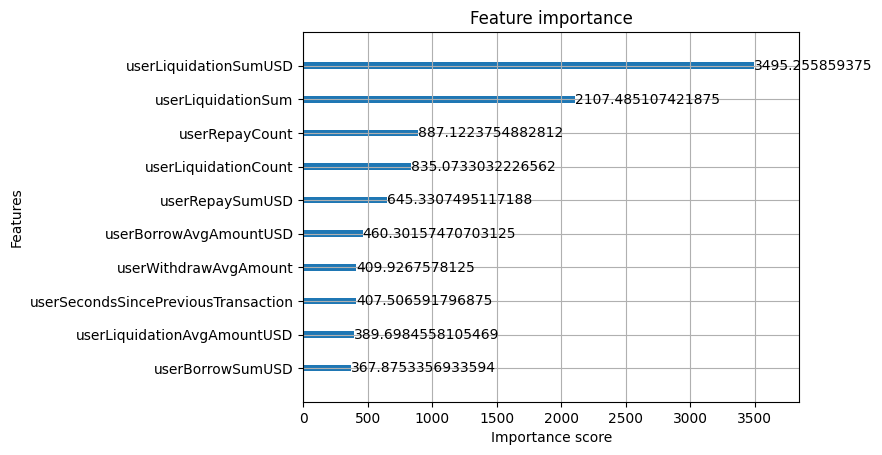

In [20]:
xgb.plot_importance(model, importance_type='gain', max_num_features=10)